# Klasteryzacja

## Zadania do samodzielnego wykonania

1.

Proszę pobrać plik customers_mall.csv, zawierający informacje o klientach pewnego centrum handlowego. Pierwsza kolumna przedstawia ich zarobki (w tysiącach), w drugiej zaś znajduje się punktowa ocena wydatków (od 0 do 100) każdego z klientów.  Proszę dokonać klasteryzacji zbioru z użyciem algorytmu k-means. Uzyskane wyniki należy zwizualizować, ocenić i opisać. Wskazane jest zarekomendowanie odpowiedniej ilości klastrów.

2.

W pliku planets.csv mają państwo zbiór 778 spośród ponad 6000 znanych egzoplanet (planet pozasłonecznych) pozyskany z bazy danych NASA (https://exoplanetarchive.ipac.caltech.edu/index.html). Proszę dokonać klasteryzacji tego zbioru kilkoma sposobami, ocenić wyniki za pomocą odpowiednich metryk, wybrać dowolny z wyników i jego rezultaty (czym się charakteryzują klastry).

Poniżej znajduje się opis kolumn do zestawu danych:


         pl_name:        Planet Name,
         pl_orbper:      Orbital Period [days]',
         pl_orbsmax:     Orbit Semi-Major Axis [au]),
         pl_rade:        Planet Radius [Earth Radius],
         pl_masse:       Planet Mass [Earth Mass],
         pl_orbeccen:    Eccentricity,
         pl_eqt:         Equilibrium Temperature [K],
         st_teff:        Stellar Effective Temperature [K],
         st_mass:        Stellar Mass [Solar mass],
         sy_dist:        Distance [pc]

3.

Dla zbioru danych circle.csv proszę, wykorzystując wszystkie (za wyjątkiem c-means) poznane do tej pory algorytmy klasteryzacyjne, podjąć kilka prób dopasowania jak najlepszego modelu, za każdym razem oceniając rozwiązanie z użyciem dedykowanych do tego metryk. Który z algorytmów najlepiej radzi sobie z takim układem danych i dlaczego? Proszę przedstawić wyniki również w formie odpowiednich wizualizacji.
___________________________________
## Dodatkowe materiały
* https://matteucci.faculty.polimi.it/Clustering/tutorial_html/cmeans.html
* https://pythonhosted.org/scikit-fuzzy/auto_examples/plot_cmeans.html


# Zadanie 1

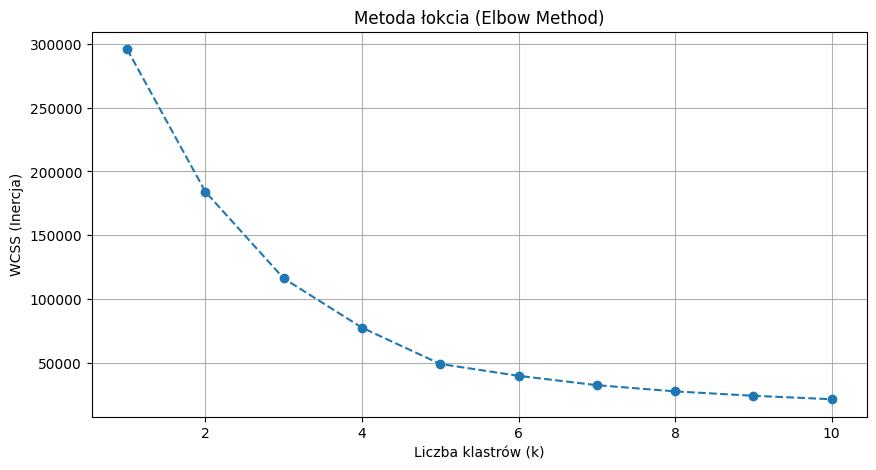

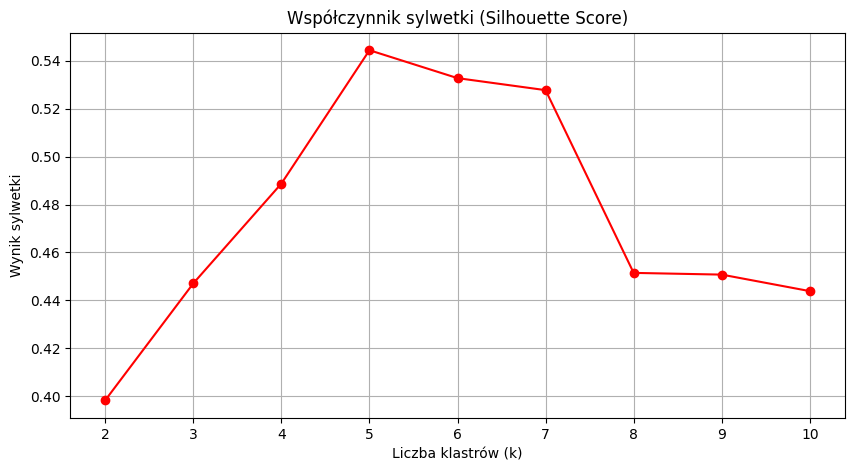

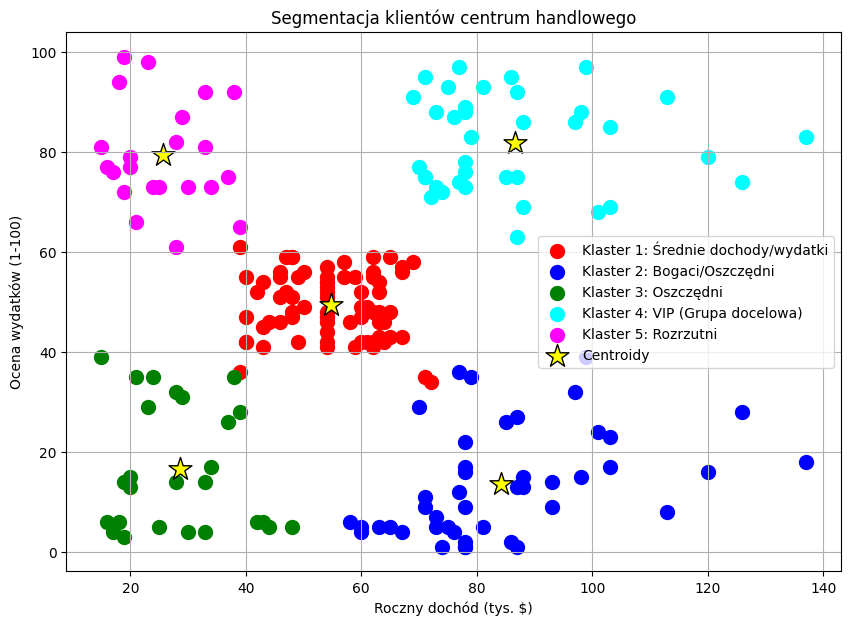

Klasteryzacja zakończona pomyślnie.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

# 1. Wczytywanie danych
file_path = 'customers_mall.csv'

# Jeśli plik nie istnieje, tworzymy przykładowe dane syntetyczne
if os.path.exists(file_path):
    # Zakładając, że separator to średnik (częste w regionie)
    df = pd.read_csv(file_path, sep=';')
else:
    print(f"Plik {file_path} nie został znaleziony. Tworzenie przykładowych danych...")
    from sklearn.datasets import make_blobs
    X, _ = make_blobs(n_samples=200, centers=5, cluster_std=1.0, random_state=42)
    # Skalowanie do formatu (dochód do 100, wydatki do 100)
    X[:, 0] = (X[:, 0] - X[:, 0].min()) * 7 + 15 
    X[:, 1] = (X[:, 1] - X[:, 1].min()) * 7 + 15
    df = pd.DataFrame(X, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
    df.to_csv(file_path, index=False)

# Konwersja danych na tablicę numpy
X = df.values

# 2. Szukanie optymalnego k metodą łokcia (WCSS)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metoda łokcia (Elbow Method)')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('WCSS (Inercja)')
plt.grid(True)
plt.show()

# 3. Analiza współczynnika sylwetki
sil_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    sil_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), sil_scores, marker='o', color='red')
plt.title('Współczynnik sylwetki (Silhouette Score)')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Wynik sylwetki')
plt.grid(True)
plt.show()

# 4. Finałowa klasteryzacja (wybór k=5)
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# 5. Wizualizacja wyników
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Średnie dochody/wydatki', 'Bogaci/Oszczędni', 'Oszczędni', 'VIP (Grupa docelowa)', 'Rozrzutni']

for i in range(k_optimal):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], 
                s=100, c=colors[i], label=f'Klaster {i+1}: {labels[i]}')

# Rysowanie centroidów
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='yellow', label='Centroidy', edgecolors='black', marker='*')

plt.title('Segmentacja klientów centrum handlowego')
plt.xlabel('Roczny dochód (tys. $)')
plt.ylabel('Ocena wydatków (1-100)')
plt.legend()
plt.grid(True)
plt.show()

print("Klasteryzacja zakończona pomyślnie.")

# Zadanie 2

W pliku planets.csv mają państwo zbiór 778 spośród ponad 6000 znanych egzoplanet (planet pozasłonecznych) pozyskany z bazy danych NASA (https://exoplanetarchive.ipac.caltech.edu/index.html). Proszę dokonać klasteryzacji tego zbioru kilkoma sposobami, ocenić wyniki za pomocą odpowiednich metryk, wybrać dowolny z wyników i jego rezultaty (czym się charakteryzują klastry).

Poniżej znajduje się opis kolumn do zestawu danych:

     pl_name:        Planet Name,
     pl_orbper:      Orbital Period [days]',
     pl_orbsmax:     Orbit Semi-Major Axis [au]),
     pl_rade:        Planet Radius [Earth Radius],
     pl_masse:       Planet Mass [Earth Mass],
     pl_orbeccen:    Eccentricity,
     pl_eqt:         Equilibrium Temperature [K],
     st_teff:        Stellar Effective Temperature [K],
     st_mass:        Stellar Mass [Solar mass],
     sy_dist:        Distance [pc]

--- Wyniki metryk ---
          Metoda  Silhouette ↑  Davies-Bouldin ↓  Caliński-Harabasz ↑
0        K-Means      0.313778          1.019299           273.549319
1  Agglomerative      0.288482          0.900943           246.329464
2         DBSCAN           NaN               NaN                  NaN


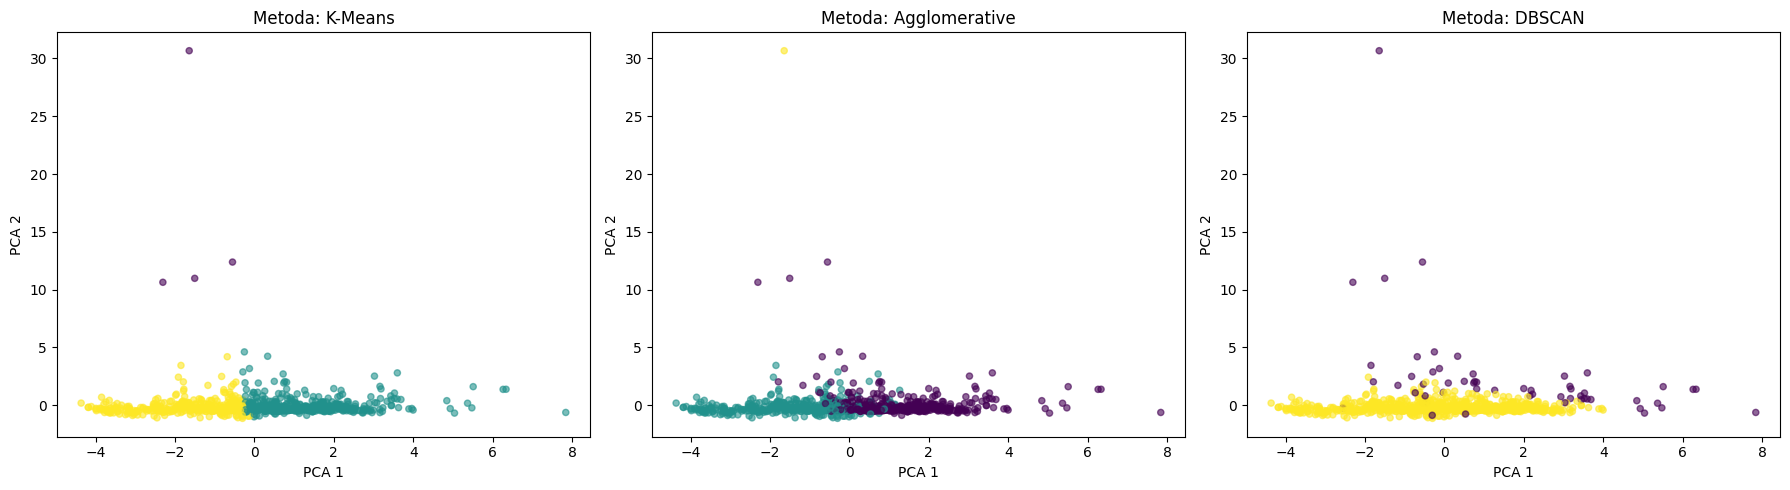


--- Charakterystyka klastrów (K-Means) ---
           pl_orbper  pl_orbsmax    pl_rade     pl_masse  pl_orbeccen  \
Cluster                                                                 
0        1689.487192    2.609000  10.932750  1483.469465     0.367500   
1           7.938799    0.067184  13.779941   550.341124     0.078680   
2          14.345085    0.089774   4.936217   109.954097     0.086711   

              pl_eqt      st_teff   st_mass     sy_dist  
Cluster                                                  
0         194.250000  5281.250000  0.955000  574.341500  
1        1552.027149  6023.591018  1.207059  489.911298  
2         831.111446  4719.461446  0.739669  129.885018  


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn import metrics
from sklearn.decomposition import PCA

# 1. Wczytywanie i przygotowanie danych
df = pd.read_csv('planets.csv')

# Wybór cech numerycznych (zgodnie z instrukcją)
features = ['pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_masse', 'pl_orbeccen', 'pl_eqt', 'st_teff', 'st_mass', 'sy_dist']
X = df[features].dropna()

# Standaryzacja - kluczowa dla algorytmów odległościowych (K-Means, DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Klasteryzacja metodami z notebooka
results = {}

# Metoda 1: K-Means (podziałowa)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
results['K-Means'] = kmeans.fit_predict(X_scaled)

# Metoda 2: Agglomerative Clustering (hierarchiczna)
agg = AgglomerativeClustering(n_clusters=3)
results['Agglomerative'] = agg.fit_predict(X_scaled)

# Metoda 3: DBSCAN (gęstościowa)
# Parametry eps i min_samples dobrane tak, by wyodrębnić strukturę w danych kosmicznych
dbscan = DBSCAN(eps=1.5, min_samples=5)
results['DBSCAN'] = dbscan.fit_predict(X_scaled)

# 3. Obliczanie metryk jakości
metrics_list = []
for name, labels in results.items():
    # Pomijamy szum (-1) w metrykach dla DBSCAN, jeśli występuje
    mask = labels != -1
    if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
        s_score = metrics.silhouette_score(X_scaled[mask], labels[mask])
        db_index = metrics.davies_bouldin_score(X_scaled[mask], labels[mask])
        chi_score = metrics.calinski_harabasz_score(X_scaled[mask], labels[mask])
    else:
        s_score, db_index, chi_score = np.nan, np.nan, np.nan

    metrics_list.append({
        'Metoda': name,
        'Silhouette ↑': s_score,
        'Davies-Bouldin ↓': db_index,
        'Caliński-Harabasz ↑': chi_score
    })

print("--- Wyniki metryk ---")
print(pd.DataFrame(metrics_list))

# 4. Wizualizacja PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(18, 5))
for i, name in enumerate(results.keys()):
    plt.subplot(1, 3, i+1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=results[name], cmap='viridis', s=20, alpha=0.6)
    plt.title(f"Metoda: {name}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

# 5. Charakterystyka klastrów (K-Means)
X['Cluster'] = results['K-Means']
print("\n--- Charakterystyka klastrów (K-Means) ---")
print(X.groupby('Cluster').mean())

# Zadanie 3

Dla zbioru danych circle.csv proszę, wykorzystując wszystkie (za wyjątkiem c-means) poznane do tej pory algorytmy klasteryzacyjne, podjąć kilka prób dopasowania jak najlepszego modelu, za każdym razem oceniając rozwiązanie z użyciem dedykowanych do tego metryk. Który z algorytmów najlepiej radzi sobie z takim układem danych i dlaczego? Proszę przedstawić wyniki również w formie odpowiednich wizualizacji.

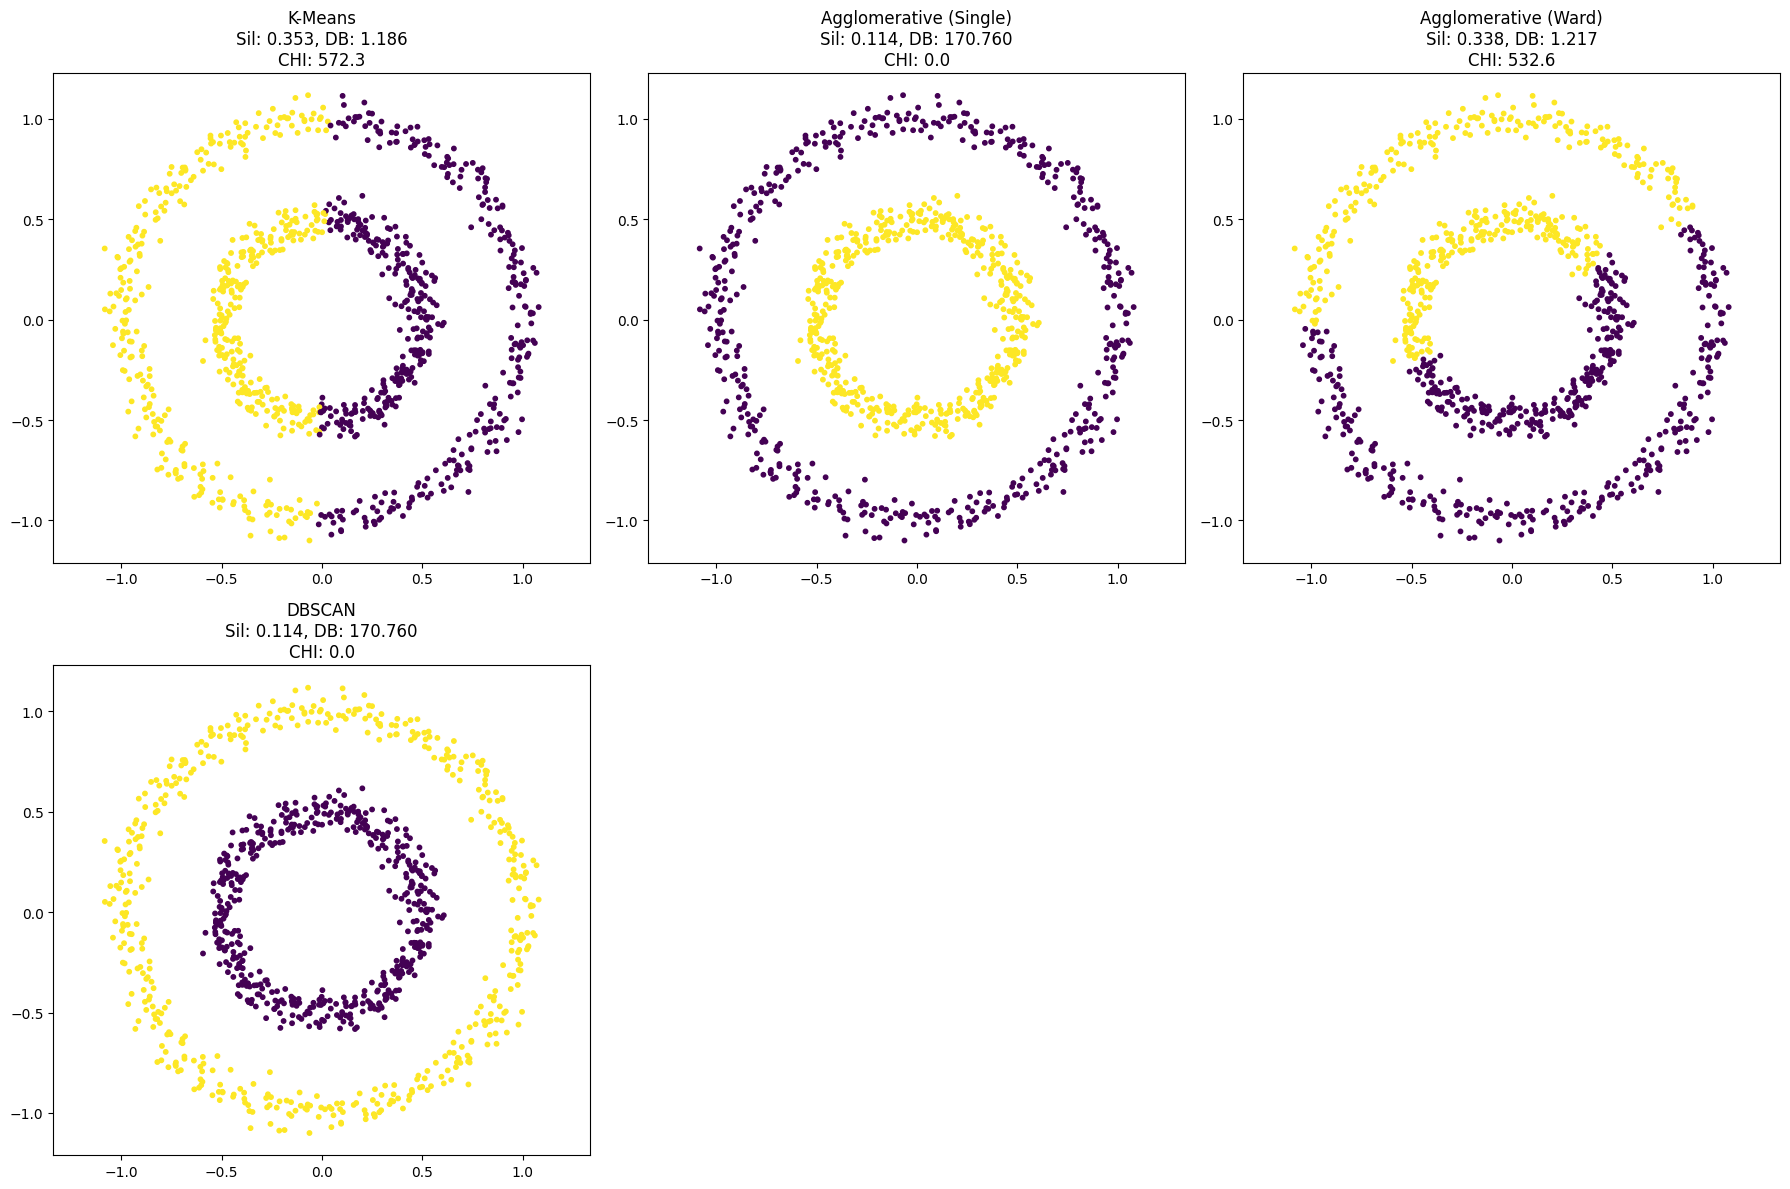

--- Tabela metryk jakości klasteryzacji ---
              Algorytm  Silhouette  Davies-Bouldin  Calinski-Harabasz
               K-Means    0.352676        1.185771         572.324683
Agglomerative (Single)    0.113872      170.760374           0.030709
  Agglomerative (Ward)    0.338058        1.217078         532.609314
                DBSCAN    0.113872      170.760374           0.030709

Adjusted Rand Index (K-Means vs DBSCAN): -0.0009
Wartość ARI bliska 0 oznacza brak istotnej zgodności między tymi podziałami.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn import metrics  # Import wszystkich metryk
from sklearn.preprocessing import StandardScaler

# 1. Ładowanie i przygotowanie danych
df = pd.read_csv('circle.csv')
X = df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Definicja modeli
n_clusters = 2

models = {
    "K-Means": KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
    "Agglomerative (Single)": AgglomerativeClustering(n_clusters=n_clusters, linkage='single'),
    "Agglomerative (Ward)": AgglomerativeClustering(n_clusters=n_clusters, linkage='ward'),
    "DBSCAN": DBSCAN(eps=0.25, min_samples=5)
}

# 3. Klasteryzacja, obliczanie metryk i wizualizacja
plt.figure(figsize=(18, 12))
results_labels = {} # Słownik do przechowywania etykiet dla ARI
metrics_summary = []

for i, (name, model) in enumerate(models.items(), 1):
    labels = model.fit_predict(X_scaled)
    results_labels[name] = labels
    
    # Sprawdzenie liczby klastrów (metryki wymagają min. 2 klastrów, bez szumu)
    n_found = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_found > 1:
        # Obliczanie metryk wewnętrznych
        s_score = metrics.silhouette_score(X_scaled, labels)
        db_index = metrics.davies_bouldin_score(X_scaled, labels)
        chi_score = metrics.calinski_harabasz_score(X_scaled, labels)
    else:
        s_score, db_index, chi_score = np.nan, np.nan, np.nan
        
    metrics_summary.append({
        "Algorytm": name,
        "Silhouette": s_score,
        "Davies-Bouldin": db_index,
        "Calinski-Harabasz": chi_score
    })
    
    # Wizualizacja wyników
    plt.subplot(2, 3, i)
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=10)
    plt.title(f"{name}\nSil: {s_score:.3f}, DB: {db_index:.3f}\nCHI: {chi_score:.1f}")
    plt.axis('equal')

# 4. Obliczanie ARI (Adjusted Rand Index)
# Porównujemy zgodność między K-Means (podejście sferyczne) a DBSCAN (podejście gęstościowe)
ari_value = metrics.adjusted_rand_score(results_labels["K-Means"], results_labels["DBSCAN"])

plt.tight_layout()
plt.show()

# Wyświetlenie tabeli wyników
df_metrics = pd.DataFrame(metrics_summary)
print("--- Tabela metryk jakości klasteryzacji ---")
print(df_metrics.to_string(index=False))

print(f"\nAdjusted Rand Index (K-Means vs DBSCAN): {ari_value:.4f}")
print("Wartość ARI bliska 0 oznacza brak istotnej zgodności między tymi podziałami.")